# Triadic Cell Notebook v47
## Candidate Verification Observables

v46 proved the local 4060 harness works, but it also exposed the failure mode:

$$
\text{full controller} \approx \text{base model}
$$

The base model scored 24/26, the full controller scored 24/26, and the gated controller scored 24/26. No help, no hurt.

The no-base and shape-only ablations were much weaker, which means the v46 controller was mostly riding base logits.

v47 changes the observable layer.

Instead of asking only:

$$
P(A), P(B), P(C), P(D)
$$

we build candidate-level observables:

1. **letter score**: log-probability of the answer letter.
2. **answer-text score**: log-probability of the candidate text as answer.
3. **verifier score**: for each candidate, ask whether the candidate is correct and score `Yes` vs `No`.
4. **embedding fit**: geometric prompt/candidate/pair structure.
5. **folded evidence energy**: collapse over all channels.

The goal is not more theory. The goal is to catch cases like:

$$
\text{base wrong with high margin}
$$

where the controller previously refused to override.


In [1]:
# Optional installs if needed:
# %pip install -q torch transformers pandas matplotlib tqdm accelerate sentence-transformers

from __future__ import annotations

import os, json, math, re
from pathlib import Path
from dataclasses import dataclass
from typing import List, Dict, Any, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForCausalLM, AutoModel

try:
    from sentence_transformers import SentenceTransformer
    HAVE_ST = True
except Exception:
    SentenceTransformer = None
    HAVE_ST = False

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
np.set_printoptions(suppress=True, precision=4)

print("torch:", torch.__version__)
print("cuda:", torch.cuda.is_available())
print("gpu:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "no cuda")
print("sentence_transformers:", HAVE_ST)


torch: 2.11.0+cu126
cuda: True
gpu: NVIDIA GeForce RTX 4060
sentence_transformers: True


In [2]:
# -----------------------------
# CONFIG
# -----------------------------
DATA_JSONL = ""      # leave empty for built-in resistance set
MAX_SAMPLES = 64

HF_TOKEN = os.getenv("HF_TOKEN", "")
LOCAL_FILES_ONLY = True

MODEL_PROFILE = "qwen25_1p5b_instruct"

MODEL_PROFILES = {
    "qwen25_1p5b_instruct": {
        "MODEL_NAME": "Qwen/Qwen2.5-1.5B-Instruct",
        "EMBED_MODEL_NAME": "sentence-transformers/all-MiniLM-L6-v2",
        "MAX_SAMPLES_CAP": 64,
    },
    "qwen25_3b_instruct": {
        "MODEL_NAME": "Qwen/Qwen2.5-3B-Instruct",
        "EMBED_MODEL_NAME": "sentence-transformers/all-MiniLM-L6-v2",
        "MAX_SAMPLES_CAP": 48,
    },
    "qwen25_coder_1p5b": {
        "MODEL_NAME": "Qwen/Qwen2.5-Coder-1.5B-Instruct",
        "EMBED_MODEL_NAME": "sentence-transformers/all-MiniLM-L6-v2",
        "MAX_SAMPLES_CAP": 64,
    },
}

profile = MODEL_PROFILES[MODEL_PROFILE]
MODEL_NAME = profile["MODEL_NAME"]
EMBED_MODEL_NAME = profile["EMBED_MODEL_NAME"]
MAX_SAMPLES = min(MAX_SAMPLES, profile["MAX_SAMPLES_CAP"])

USE_CHAT_TEMPLATE = True

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.float16 if DEVICE == "cuda" else torch.float32

# override thresholds
EVIDENCE_OVERRIDE_MARGIN = 0.18
VERIFIER_OVERRIDE_MARGIN = 0.12
BASE_LOCK_MARGIN = 2.50   # very high base margin; can still be broken by verifier

OUTPUT_DIR = f"v47_outputs_{MODEL_PROFILE}"
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

print("MODEL:", MODEL_NAME)
print("EMBED:", EMBED_MODEL_NAME)
print("LOCAL_FILES_ONLY:", LOCAL_FILES_ONLY)
print("DEVICE:", DEVICE, "DTYPE:", DTYPE)
print("OUTPUT_DIR:", OUTPUT_DIR)


MODEL: Qwen/Qwen2.5-1.5B-Instruct
EMBED: sentence-transformers/all-MiniLM-L6-v2
LOCAL_FILES_ONLY: True
DEVICE: cuda DTYPE: torch.float16
OUTPUT_DIR: v47_outputs_qwen25_1p5b_instruct


In [3]:
RESISTANCE_DATA = [
    {"id":"easy_1","band":"easy","prompt":"Which planet is known as the Red Planet?","choices":["Earth","Mars","Venus","Jupiter"],"answer_idx":1},
    {"id":"easy_2","band":"easy","prompt":"What gas do plants primarily absorb from the atmosphere?","choices":["Oxygen","Hydrogen","Carbon dioxide","Nitrogen"],"answer_idx":2},
    {"id":"easy_3","band":"easy","prompt":"What is the capital of Japan?","choices":["Beijing","Seoul","Tokyo","Kyoto"],"answer_idx":2},
    {"id":"easy_4","band":"easy","prompt":"Which number is prime?","choices":["21","35","37","49"],"answer_idx":2},

    {"id":"amb_1","band":"ambiguous","prompt":"Which term best means 'able to be understood in more than one way'?","choices":["accurate","ambiguous","literal","obsolete"],"answer_idx":1},
    {"id":"amb_2","band":"ambiguous","prompt":"A system returns to stable behavior after a disturbance. Which term fits best?","choices":["fragile","resilient","random","orthogonal"],"answer_idx":1},
    {"id":"amb_3","band":"ambiguous","prompt":"Which choice best describes a boundary that controls what can pass through it?","choices":["interface","archive","constant","duplicate"],"answer_idx":0},
    {"id":"amb_4","band":"ambiguous","prompt":"Which word best describes hiding implementation details behind a simple public surface?","choices":["encapsulation","translation","recursion","pagination"],"answer_idx":0},
    {"id":"amb_5","band":"ambiguous","prompt":"Which term means a stable repeating behavior that a dynamic system tends toward?","choices":["attractor","exception","literal","syntax"],"answer_idx":0},
    {"id":"amb_6","band":"ambiguous","prompt":"Which operation most directly combines parts under a constraint?","choices":["coupling","deletion","naming","printing"],"answer_idx":0},

    {"id":"trap_1","band":"trap","prompt":"A database index helps find rows quickly. Which item is most like an index?","choices":["a printed book cover","a map from key to location","a random password","a paint color"],"answer_idx":1},
    {"id":"trap_2","band":"trap","prompt":"In code, a function named getUser() should most directly do what?","choices":["delete all users","return a user or user data","compile the database","change the server clock"],"answer_idx":1},
    {"id":"trap_3","band":"trap","prompt":"A cache is useful mainly because it:","choices":["stores recent results for faster reuse","guarantees truth forever","removes all memory use","encrypts every variable"],"answer_idx":0},
    {"id":"trap_4","band":"trap","prompt":"If a pipe adapter must connect two different diameters, the important property is:","choices":["matching the paint","fitting both ends","being the heaviest piece","having the longest name"],"answer_idx":1},
    {"id":"trap_5","band":"trap","prompt":"If a prompt asks for only the final letter A-D, the safest output format is:","choices":["a paragraph explaining all choices","the single selected letter","a JSON object with citations","a poem"],"answer_idx":1},
    {"id":"trap_6","band":"trap","prompt":"A screwdriver works because its tip shape matches the screw slot. What is the key relation?","choices":["semantic similarity","geometric fit","calendar order","file size"],"answer_idx":1},

    {"id":"logic_1","band":"logic","prompt":"All bloops are razzies. Some razzies are lazzies. Which must be true?","choices":["All bloops are lazzies","Some lazzies are bloops","All bloops are razzies","No razzies are bloops"],"answer_idx":2},
    {"id":"logic_2","band":"logic","prompt":"If the switch is off, the lamp is dark. The lamp is not dark. What follows?","choices":["The switch is off","The switch is not off","The lamp is broken","Nothing follows"],"answer_idx":1},
    {"id":"logic_3","band":"logic","prompt":"A box contains red and blue balls. You remove all red balls. What can remain?","choices":["only red balls","blue balls or nothing","red and blue balls","a guaranteed blue ball"],"answer_idx":1},
    {"id":"logic_4","band":"logic","prompt":"You need a tool that applies torque to a hex bolt. Which is the best fit?","choices":["paintbrush","wrench","thermometer","bookmark"],"answer_idx":1},
    {"id":"logic_5","band":"logic","prompt":"If every valid answer must satisfy constraints A and B, which candidate is valid?","choices":["satisfies A only","satisfies B only","satisfies A and B","satisfies neither"],"answer_idx":2},
    {"id":"logic_6","band":"logic","prompt":"A thing is useful here only if it fits the socket and can carry current. Which candidate is best?","choices":["decorative plug-shaped toy","electrical plug with matching prongs","loose wire with no connector","wooden dowel"],"answer_idx":1},

    {"id":"shape_1","band":"shape","prompt":"A loose round coupler needs temporary compression around its outside. Which available item most directly supplies that shape?","choices":["tight O-rings","flat sheet of paper","loose string lying straight","a marker cap"],"answer_idx":0},
    {"id":"shape_2","band":"shape","prompt":"A tent must become portable without destroying shelter function. What is the central operation?","choices":["folding into a smaller carried form","painting it darker","renaming it","removing all poles forever"],"answer_idx":0},
    {"id":"shape_3","band":"shape","prompt":"A chair must occupy less storage space while remaining recoverable as a chair. What design feature solves this?","choices":["folding joints","heavier legs","larger fabric","permanent glue"],"answer_idx":0},
    {"id":"shape_4","band":"shape","prompt":"A car interface hides engine complexity from the driver. Which surface is the simplified control?","choices":["accelerator pedal","piston ring gap","camshaft lobe profile","fuel injector spray cone"],"answer_idx":0},
]

def load_jsonl(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line=line.strip()
            if line:
                rows.append(json.loads(line))
    return rows

def clean_rows(rows):
    out=[]
    for i,row in enumerate(rows[:MAX_SAMPLES]):
        if not all(k in row for k in ("prompt","choices","answer_idx")):
            print("skip bad row:", row); continue
        if not isinstance(row["choices"], list) or len(row["choices"]) < 2:
            print("skip bad choices:", row); continue
        a=int(row["answer_idx"])
        if not (0 <= a < len(row["choices"])):
            print("skip bad answer_idx:", row); continue
        out.append({
            "id": row.get("id", f"row_{i}"),
            "band": row.get("band", "unknown"),
            "prompt": str(row["prompt"]),
            "choices": [str(x) for x in row["choices"]],
            "answer_idx": a,
        })
    return out

rows = clean_rows(load_jsonl(DATA_JSONL) if DATA_JSONL and Path(DATA_JSONL).exists() else RESISTANCE_DATA)
print("rows:", len(rows))
pd.DataFrame(rows).head()


rows: 26


,id,band,prompt,choices,answer_idx
0,easy_1,easy,Which planet is known as the Red Planet?,"[Earth, Mars, Venus, Jupiter]",1
1,easy_2,easy,What gas do plants primarily absorb from the a...,"[Oxygen, Hydrogen, Carbon dioxide, Nitrogen]",2
2,easy_3,easy,What is the capital of Japan?,"[Beijing, Seoul, Tokyo, Kyoto]",2
3,easy_4,easy,Which number is prime?,"[21, 35, 37, 49]",2
4,amb_1,ambiguous,Which term best means 'able to be understood i...,"[accurate, ambiguous, literal, obsolete]",1


In [4]:
def hf_kwargs():
    kw = {"local_files_only": LOCAL_FILES_ONLY}
    if HF_TOKEN:
        kw["token"] = HF_TOKEN
    return kw

print("Loading tokenizer/model...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True, **hf_kwargs())
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

lm = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    dtype=DTYPE,
    device_map="auto" if DEVICE == "cuda" else None,
    **hf_kwargs(),
)
if DEVICE != "cuda":
    lm = lm.to(DEVICE)
lm.eval()
print("Loaded model:", MODEL_NAME)

if EMBED_MODEL_NAME and HAVE_ST:
    print("Using SentenceTransformer embedder")
    embedder = SentenceTransformer(EMBED_MODEL_NAME, device=DEVICE)
else:
    raise RuntimeError("SentenceTransformer embedder required for this notebook. Install sentence-transformers or cache all-MiniLM-L6-v2.")


Loading tokenizer/model...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Loaded model: Qwen/Qwen2.5-1.5B-Instruct
Using SentenceTransformer embedder


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [5]:
LETTERS="ABCDEFGHIJKLMNOPQRSTUVWXYZ"

def build_mcq_prompt(row):
    parts=[row["prompt"].strip(), "", "Choices:"]
    for i,c in enumerate(row["choices"]):
        parts.append(f"{LETTERS[i]}. {c}")
    parts += ["", "Answer with the single correct letter only."]
    return "\n".join(parts)

def maybe_chat(prompt):
    if USE_CHAT_TEMPLATE and hasattr(tokenizer, "apply_chat_template"):
        try:
            return tokenizer.apply_chat_template([{"role":"user","content":prompt}], tokenize=False, add_generation_prompt=True)
        except Exception:
            pass
    return prompt

def conditional_logprob(prefix, suffix):
    prefix_ids=tokenizer(prefix, return_tensors="pt", add_special_tokens=False)["input_ids"].to(DEVICE)
    full_ids=tokenizer(prefix+suffix, return_tensors="pt", add_special_tokens=False)["input_ids"].to(DEVICE)
    with torch.no_grad():
        out=lm(full_ids)
        logits=out.logits[:,:-1,:]
        targets=full_ids[:,1:]
        lp=F.log_softmax(logits, dim=-1).gather(-1, targets.unsqueeze(-1)).squeeze(-1)
    start=max(prefix_ids.shape[1]-1, 0)
    return float(lp[:,start:].mean().item())

def normalize_scores(x):
    x=np.array(x,dtype=np.float32)
    return (x-x.mean())/(x.std()+1e-8)

def margin_of(scores):
    order=np.sort(np.array(scores))[::-1]
    return float(order[0]-order[1]) if len(order)>1 else 0.0

def score_base(row):
    p=build_mcq_prompt(row)
    rendered=maybe_chat(p)
    scores=np.array([conditional_logprob(rendered, " "+LETTERS[i]) for i in range(len(row["choices"]))], dtype=np.float32)
    pred=int(np.argmax(scores))
    prob=np.exp(scores-scores.max()); prob=prob/(prob.sum()+1e-8)
    ent=float(-np.sum(prob*np.log(prob+1e-8)))
    return p, scores, prob.astype(np.float32), pred, margin_of(scores), ent

def score_answer_text(row, prompt_text):
    prefix = maybe_chat(prompt_text + "\n\nThe answer is")
    scores=[]
    for choice in row["choices"]:
        scores.append(conditional_logprob(prefix, " " + choice))
    return np.array(scores,dtype=np.float32)

def verifier_prompt(row, choice):
    parts=[
        row["prompt"].strip(),
        "",
        "Choices:"
    ]
    for i,c in enumerate(row["choices"]):
        parts.append(f"{LETTERS[i]}. {c}")
    parts += [
        "",
        f"Candidate answer: {choice}",
        "Is the candidate answer correct?",
        "Answer Yes or No."
    ]
    return "\n".join(parts)

def score_verifier(row):
    margins=[]
    yes_scores=[]
    no_scores=[]
    for choice in row["choices"]:
        p=maybe_chat(verifier_prompt(row, choice))
        y=conditional_logprob(p, " Yes")
        n=conditional_logprob(p, " No")
        yes_scores.append(y)
        no_scores.append(n)
        margins.append(y-n)
    return np.array(margins,dtype=np.float32), np.array(yes_scores,dtype=np.float32), np.array(no_scores,dtype=np.float32)

print("Scoring primitives loaded.")


Scoring primitives loaded.


In [6]:
@dataclass
class V47Sample:
    row_id: str
    band: str
    prompt_text: str
    choices: list
    answer_idx: int
    base_scores: np.ndarray
    answer_text_scores: np.ndarray
    verifier_margins: np.ndarray
    verifier_yes: np.ndarray
    verifier_no: np.ndarray
    base_pred_idx: int
    base_margin: float
    base_entropy: float
    prompt_vec: np.ndarray
    candidate_vecs: np.ndarray
    pair_vecs: np.ndarray

scored=[]
prompt_texts=[]
choice_texts=[]
pair_texts=[]

for row in tqdm(rows, desc="Scoring base/text/verifier"):
    p,base_scores,base_probs,base_pred,base_margin,base_ent=score_base(row)
    text_scores=score_answer_text(row,p)
    ver_margins, ver_yes, ver_no = score_verifier(row)

    scored.append((row,p,base_scores,text_scores,ver_margins,ver_yes,ver_no,base_pred,base_margin,base_ent))
    prompt_texts.append(p)
    for i,c in enumerate(row["choices"]):
        choice_texts.append(f"{LETTERS[i]}. {c}")
        pair_texts.append(p+"\n\nCandidate: "+f"{LETTERS[i]}. {c}")

prompt_embs = embedder.encode(prompt_texts, batch_size=32, convert_to_numpy=True, normalize_embeddings=True, show_progress_bar=True).astype(np.float32)
choice_embs = embedder.encode(choice_texts, batch_size=32, convert_to_numpy=True, normalize_embeddings=True, show_progress_bar=True).astype(np.float32)
pair_embs = embedder.encode(pair_texts, batch_size=32, convert_to_numpy=True, normalize_embeddings=True, show_progress_bar=True).astype(np.float32)

def l2norm(x, eps=1e-8):
    return x/np.clip(np.linalg.norm(x, axis=-1, keepdims=True), eps, None)

def minmax_local(stack, eps=1e-8):
    mn=stack.min(axis=0, keepdims=True); mx=stack.max(axis=0, keepdims=True)
    return (stack-mn)/np.clip(mx-mn, eps, None)

samples=[]; cp=0; pp=0
for pi,(row,p,base_scores,text_scores,ver_margins,ver_yes,ver_no,base_pred,base_margin,base_ent) in enumerate(scored):
    n=len(row["choices"])
    cand=choice_embs[cp:cp+n]
    pair=pair_embs[pp:pp+n]
    stack=minmax_local(l2norm(np.vstack([prompt_embs[pi:pi+1], cand, pair]).astype(np.float32)))
    samples.append(V47Sample(
        row["id"], row["band"], p, row["choices"], row["answer_idx"],
        base_scores, text_scores, ver_margins, ver_yes, ver_no,
        base_pred, base_margin, base_ent,
        stack[0], stack[1:1+n], stack[1+n:1+n+n]
    ))
    cp += n
    pp += n

print("prepared:", len(samples))


Scoring base/text/verifier:   0%|          | 0/26 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

prepared: 26


## Folded evidence energy

Each candidate gets a vector of independent-ish observables:

$$
o_i =
[
z_{letter},
z_{answerText},
z_{verifier},
fit(prompt,candidate),
fit(prompt+candidate,candidate),
gap_i
]
$$

We collapse to energy:

$$
E_i =
-w_1 z_{letter}
-w_2 z_{answerText}
-w_3 z_{verifier}
-w_4 fit_i
-w_5 gap_i
+w_6 contradiction_i
$$

The selected answer is:

$$
\hat{i}=\arg\min_i E_i
$$


In [7]:
def cos(a,b):
    return float(np.dot(a,b)/((np.linalg.norm(a)+1e-8)*(np.linalg.norm(b)+1e-8)))

def softmax_np(x):
    x=np.array(x,dtype=np.float32)
    z=x-x.max()
    e=np.exp(z)
    return e/(e.sum()+1e-8)

def folded_evidence(sample: V47Sample):
    k=len(sample.choices)

    letter_z=normalize_scores(sample.base_scores)
    text_z=normalize_scores(sample.answer_text_scores)
    ver_z=normalize_scores(sample.verifier_margins)

    prompt_fit=np.array([cos(sample.prompt_vec, sample.candidate_vecs[i]) for i in range(k)],dtype=np.float32)
    pair_fit=np.array([cos(sample.pair_vecs[i], sample.candidate_vecs[i]) for i in range(k)],dtype=np.float32)

    prompt_fit_z=normalize_scores(prompt_fit)
    pair_fit_z=normalize_scores(pair_fit)

    # candidate gap: how distinct this candidate is from the rest
    gap=[]
    for i in range(k):
        others=[sample.candidate_vecs[j] for j in range(k) if j!=i]
        other_mean=np.mean(np.stack(others),axis=0)
        gap.append(np.mean(np.abs(sample.candidate_vecs[i]-other_mean)))
    gap=np.array(gap,dtype=np.float32)
    gap_z=normalize_scores(gap)

    # contradiction: high if verifier says no, or if text score conflicts with verifier
    contradiction=np.maximum(0.0, -ver_z) + 0.25*np.abs(letter_z-ver_z)
    contradiction_z=normalize_scores(contradiction)

    # energy: lower is better
    energy=(
        -0.40*letter_z
        -0.25*text_z
        -0.85*ver_z
        -0.20*prompt_fit_z
        -0.20*pair_fit_z
        -0.15*gap_z
        +0.35*contradiction_z
    )

    pred=int(np.argmin(energy))
    evidence_strength=margin_of(-energy)

    table=pd.DataFrame({
        "choice_idx":list(range(k)),
        "choice":sample.choices,
        "letter_score":sample.base_scores,
        "answer_text_score":sample.answer_text_scores,
        "verifier_margin_yes_minus_no":sample.verifier_margins,
        "letter_z":letter_z,
        "text_z":text_z,
        "verifier_z":ver_z,
        "prompt_fit":prompt_fit,
        "pair_fit":pair_fit,
        "gap_z":gap_z,
        "contradiction_z":contradiction_z,
        "energy":energy,
    })

    return pred, float(evidence_strength), table

def verifier_pred(sample):
    pred=int(np.argmax(sample.verifier_margins))
    return pred, margin_of(sample.verifier_margins)

def answer_text_pred(sample):
    pred=int(np.argmax(sample.answer_text_scores))
    return pred, margin_of(sample.answer_text_scores)

def gate_v47(sample, evidence_pred, evidence_margin, verifier_p, verifier_margin):
    base_pred=sample.base_pred_idx
    if evidence_pred == base_pred:
        return base_pred, "same_as_base"

    # allow verifier to break even high base margin
    if verifier_p == evidence_pred and verifier_margin >= VERIFIER_OVERRIDE_MARGIN and evidence_margin >= EVIDENCE_OVERRIDE_MARGIN:
        return evidence_pred, "override_verifier_and_evidence"

    # very high base stays unless verifier is decisive
    if sample.base_margin >= BASE_LOCK_MARGIN:
        return base_pred, "keep_base_locked"

    if evidence_margin >= EVIDENCE_OVERRIDE_MARGIN:
        return evidence_pred, "override_evidence_margin"

    return base_pred, "keep_base_default"

rows_out=[]
evidence_tables={}

for s in samples:
    evidence_pred,evidence_margin,tab=folded_evidence(s)
    evidence_tables[s.row_id]=tab
    ver_p,ver_margin=verifier_pred(s)
    text_p,text_margin=answer_text_pred(s)
    gated_p,gate_reason=gate_v47(s,evidence_pred,evidence_margin,ver_p,ver_margin)

    rows_out.append({
        "id":s.row_id,
        "band":s.band,
        "gold_idx":s.answer_idx,
        "gold_choice":s.choices[s.answer_idx],

        "base_idx":s.base_pred_idx,
        "base_choice":s.choices[s.base_pred_idx],
        "base_correct":int(s.base_pred_idx==s.answer_idx),
        "base_margin":s.base_margin,
        "base_entropy":s.base_entropy,

        "answer_text_idx":text_p,
        "answer_text_choice":s.choices[text_p],
        "answer_text_correct":int(text_p==s.answer_idx),
        "answer_text_margin":text_margin,

        "verifier_idx":ver_p,
        "verifier_choice":s.choices[ver_p],
        "verifier_correct":int(ver_p==s.answer_idx),
        "verifier_margin":ver_margin,

        "evidence_idx":evidence_pred,
        "evidence_choice":s.choices[evidence_pred],
        "evidence_correct":int(evidence_pred==s.answer_idx),
        "evidence_margin":evidence_margin,

        "gated_idx":gated_p,
        "gated_choice":s.choices[gated_p],
        "gated_correct":int(gated_p==s.answer_idx),
        "gate_reason":gate_reason,
    })

results_df=pd.DataFrame(rows_out)
results_df["evidence_helped"]=((results_df.base_correct==0)&(results_df.evidence_correct==1)).astype(int)
results_df["evidence_hurt"]=((results_df.base_correct==1)&(results_df.evidence_correct==0)).astype(int)
results_df["gated_helped"]=((results_df.base_correct==0)&(results_df.gated_correct==1)).astype(int)
results_df["gated_hurt"]=((results_df.base_correct==1)&(results_df.gated_correct==0)).astype(int)

def acc(s): return float(s.mean()) if len(s) else float("nan")

summary=pd.DataFrame([{
    "n":len(results_df),
    "base_acc":acc(results_df.base_correct),
    "answer_text_acc":acc(results_df.answer_text_correct),
    "verifier_acc":acc(results_df.verifier_correct),
    "evidence_acc":acc(results_df.evidence_correct),
    "gated_acc":acc(results_df.gated_correct),
    "evidence_gain":acc(results_df.evidence_correct)-acc(results_df.base_correct),
    "gated_gain":acc(results_df.gated_correct)-acc(results_df.base_correct),
    "evidence_helped":int(results_df.evidence_helped.sum()),
    "evidence_hurt":int(results_df.evidence_hurt.sum()),
    "gated_helped":int(results_df.gated_helped.sum()),
    "gated_hurt":int(results_df.gated_hurt.sum()),
}])

by_band=results_df.groupby("band")[[
    "base_correct","answer_text_correct","verifier_correct","evidence_correct","gated_correct",
    "evidence_helped","evidence_hurt","gated_helped","gated_hurt"
]].mean().reset_index()

interesting=results_df[
    (results_df.base_correct==0)
    | (results_df.evidence_idx != results_df.base_idx)
    | (results_df.gated_idx != results_df.base_idx)
].copy()

display(summary)
display(by_band)
display(interesting[[
    "id","band","gold_choice",
    "base_choice","base_correct","base_margin",
    "verifier_choice","verifier_correct","verifier_margin",
    "evidence_choice","evidence_correct","evidence_margin",
    "gated_choice","gated_correct","gate_reason"
]])


,n,base_acc,answer_text_acc,verifier_acc,evidence_acc,gated_acc,evidence_gain,gated_gain,evidence_helped,evidence_hurt,gated_helped,gated_hurt
0,26,0.923077,0.807692,0.884615,0.923077,0.923077,0.0,0.0,0,0,0,0


,band,base_correct,answer_text_correct,verifier_correct,evidence_correct,gated_correct,evidence_helped,evidence_hurt,gated_helped,gated_hurt
0,ambiguous,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,0.0,0.0,0.0
1,easy,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,0.0,0.0,0.0
2,logic,0.833333,0.666667,0.666667,0.833333,0.833333,0.0,0.0,0.0,0.0
3,shape,0.750000,0.500000,0.750000,0.750000,0.750000,0.0,0.0,0.0,0.0
4,trap,1.000000,0.833333,1.000000,1.000000,1.000000,0.0,0.0,0.0,0.0


,id,band,gold_choice,base_choice,base_correct,base_margin,verifier_choice,verifier_correct,verifier_margin,evidence_choice,evidence_correct,evidence_margin,gated_choice,gated_correct,gate_reason
16,logic_1,logic,All bloops are razzies,Some lazzies are bloops,0,1.296875,No razzies are bloops,0,1.015625,No razzies are bloops,0,0.910466,No razzies are bloops,0,override_verifier_and_evidence
22,shape_1,shape,tight O-rings,loose string lying straight,0,4.203125,loose string lying straight,0,0.992188,loose string lying straight,0,3.528545,loose string lying straight,0,same_as_base


In [8]:
out=Path(OUTPUT_DIR)
results_df.to_csv(out/"results.csv", index=False)
summary.to_csv(out/"summary.csv", index=False)
by_band.to_csv(out/"by_band.csv", index=False)
interesting.to_csv(out/"interesting_cases.csv", index=False)

for row_id,tab in evidence_tables.items():
    tab.to_csv(out/f"evidence_{row_id}.csv", index=False)

print("Saved outputs in", out)
print("results.csv")
print("summary.csv")
print("by_band.csv")
print("interesting_cases.csv")
print("evidence_*.csv")


Saved outputs in v47_outputs_qwen25_1p5b_instruct
results.csv
summary.csv
by_band.csv
interesting_cases.csv
evidence_*.csv


<Figure size 900x400 with 0 Axes>

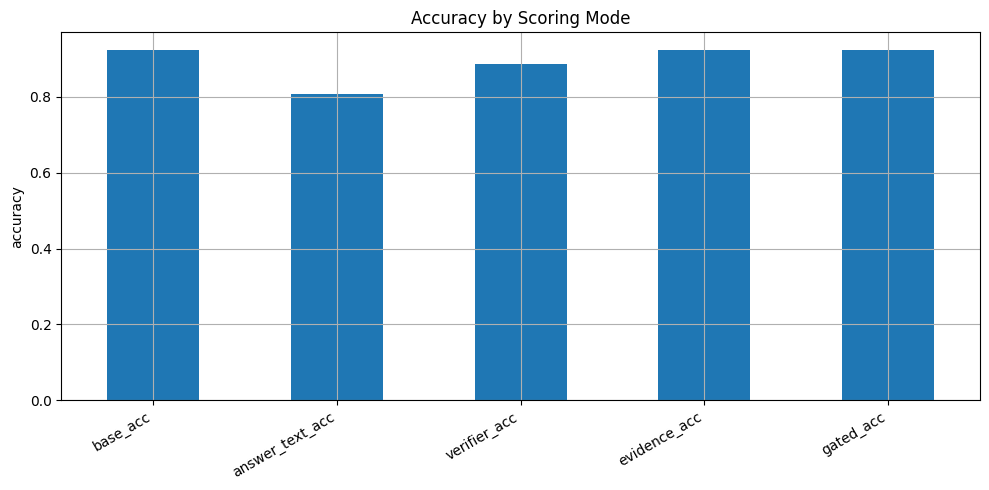

<Figure size 1100x500 with 0 Axes>

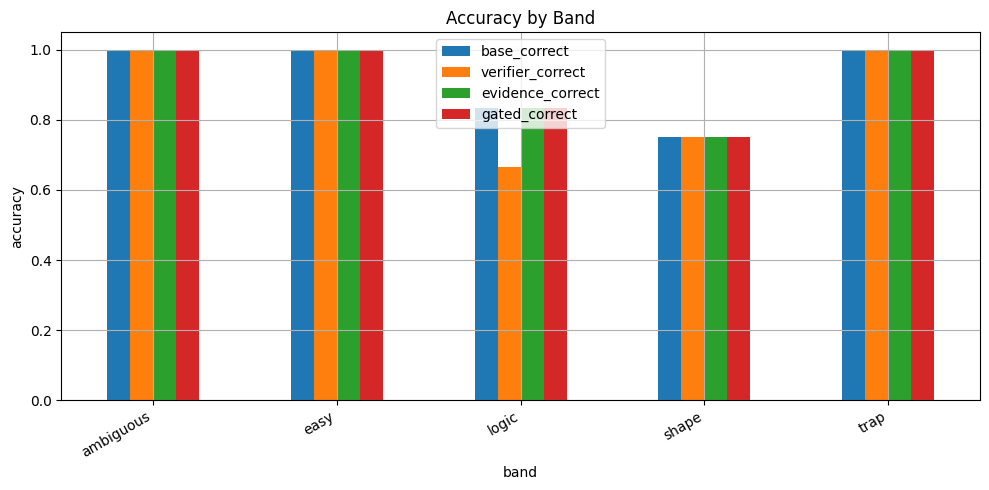

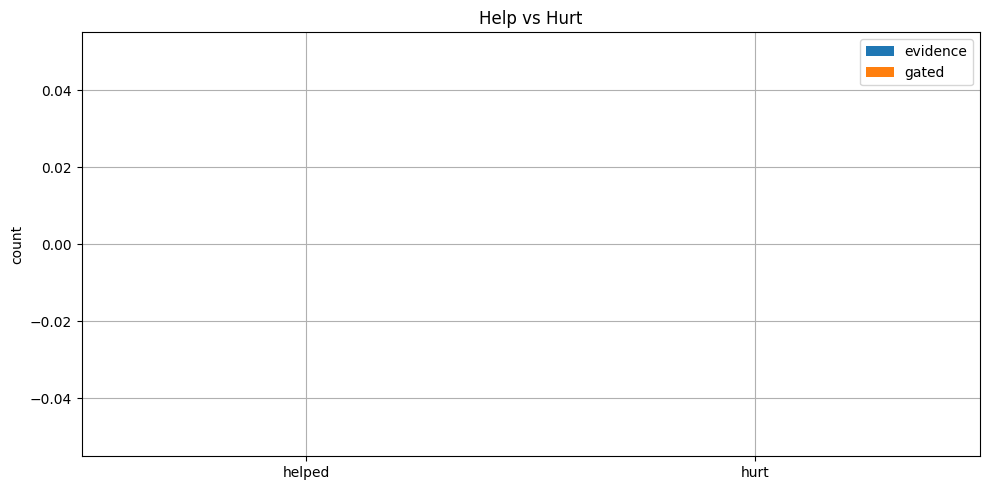

In [9]:
plt.figure(figsize=(9,4))
summary[["base_acc","answer_text_acc","verifier_acc","evidence_acc","gated_acc"]].T.plot(kind="bar", legend=False)
plt.title("Accuracy by Scoring Mode")
plt.ylabel("accuracy")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(11,5))
by_band.set_index("band")[["base_correct","verifier_correct","evidence_correct","gated_correct"]].plot(kind="bar")
plt.title("Accuracy by Band")
plt.ylabel("accuracy")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

pd.DataFrame({
    "evidence":[results_df.evidence_helped.sum(), results_df.evidence_hurt.sum()],
    "gated":[results_df.gated_helped.sum(), results_df.gated_hurt.sum()],
}, index=["helped","hurt"]).plot(kind="bar")
plt.title("Help vs Hurt")
plt.ylabel("count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [10]:
# Inspect evidence tables for cases that matter
for row_id in interesting["id"].head(8):
    print("="*100)
    print("CASE:", row_id)
    display(results_df[results_df.id==row_id][[
        "id","band","gold_choice","base_choice","base_correct","base_margin",
        "verifier_choice","verifier_correct","verifier_margin",
        "evidence_choice","evidence_correct","evidence_margin",
        "gated_choice","gated_correct","gate_reason"
    ]])
    display(evidence_tables[row_id].sort_values("energy"))


CASE: logic_1


,id,band,gold_choice,base_choice,base_correct,base_margin,verifier_choice,verifier_correct,verifier_margin,evidence_choice,evidence_correct,evidence_margin,gated_choice,gated_correct,gate_reason
16,logic_1,logic,All bloops are razzies,Some lazzies are bloops,0,1.296875,No razzies are bloops,0,1.015625,No razzies are bloops,0,0.910466,No razzies are bloops,0,override_verifier_and_evidence


,choice_idx,choice,letter_score,answer_text_score,verifier_margin_yes_minus_no,letter_z,text_z,verifier_z,prompt_fit,pair_fit,gap_z,contradiction_z,energy
3,3,No razzies are bloops,-20.843750,-3.625000,1.617188,-0.178234,0.700924,1.226893,0.555550,0.569369,1.206311,-0.568272,-1.851860
1,1,Some lazzies are bloops,-17.281250,-3.636719,0.601562,1.091681,0.676112,0.563708,0.474510,0.485854,0.704032,-1.003999,-0.941394
2,2,All bloops are razzies,-18.578125,-3.796875,-0.812500,0.629387,0.337022,-0.359651,0.520482,0.527684,-0.620173,-0.060338,0.150766
0,0,All bloops are lazzies,-24.671875,-4.765625,-2.453125,-1.542834,-1.714058,-1.430950,0.577484,0.560595,-1.290169,1.632609,2.642487


CASE: shape_1


,id,band,gold_choice,base_choice,base_correct,base_margin,verifier_choice,verifier_correct,verifier_margin,evidence_choice,evidence_correct,evidence_margin,gated_choice,gated_correct,gate_reason
22,shape_1,shape,tight O-rings,loose string lying straight,0,4.203125,loose string lying straight,0,0.992188,loose string lying straight,0,3.528545,loose string lying straight,0,same_as_base


,choice_idx,choice,letter_score,answer_text_score,verifier_margin_yes_minus_no,letter_z,text_z,verifier_z,prompt_fit,pair_fit,gap_z,contradiction_z,energy
2,2,loose string lying straight,-18.734375,-5.585938,-0.984375,1.563580,0.636196,1.349994,0.660643,0.698349,-0.609704,-1.348463,-2.718802
1,1,flat sheet of paper,-22.937500,-5.746094,-3.742188,0.043786,0.588070,-0.836006,0.607608,0.660435,0.783965,0.760325,0.809743
0,0,tight O-rings,-24.281250,-6.019531,-4.046875,-0.442096,0.505905,-1.077518,0.656407,0.686612,1.137301,1.139823,0.885099
3,3,a marker cap,-26.281250,-13.460938,-1.976562,-1.165269,-1.730170,0.563530,0.568964,0.616153,-1.311564,-0.551685,1.023960


## Readout rules

### LOCK

A real repair signal appears when:

$$
\text{base wrong} \land \text{evidence/gated correct}
$$

### NON-LOCK

If verifier, evidence, and gated all match base exactly:

$$
\text{no independent observable was added}
$$

### Ω

If verifier corrects logic but hurts shape, split controllers by band:

$$
\Omega_{\text{band}} = \text{different tasks need different observable weights}
$$

### Next fold

If v47 helps on the two v46 failures, we lock the idea that the missing piece was **candidate verification observables**, not more recursion cycles.
